In [1]:
!pip install pandas
!pip install yfinance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
#Initial Data on Stocks and Shares
#I'm creating a new data frame to store it in

data = {
    "Date": ["02-01-26","02-01-26","02-01-26","14-01-26","21-01-26","21-01-26"],
    "Ticker": ["BAB.L", "LLOY.L", "BARC.L", "NAVY.L", "GLEN.L", "BA.L"],
    "Action": ["Buy"]*6,
    "Shares": [7,69,11,5,5,2],
    "Price": [12.70,0.99,4.80,9.49,5.02,20.50],
    "Market Value": [88.90,68.31,52.80,47.45,25.10,41.00] #Share * Price
}

df = pd.DataFrame(data)
df

,Date,Ticker,Action,Shares,Price,Market Value
0,02-01-26,BAB.L,Buy,7,12.70,88.90
1,02-01-26,LLOY.L,Buy,69,0.99,68.31
2,02-01-26,BARC.L,Buy,11,4.80,52.80
3,14-01-26,NAVY.L,Buy,5,9.49,47.45
4,21-01-26,GLEN.L,Buy,5,5.02,25.10
5,21-01-26,BA.L,Buy,2,20.50,41.00


In [3]:
#Importing yfinance to obtain live stock market prices for each of the stocks
#I will use the live prices further on in the project to compare to prices I paid for each stock

import yfinance as yf

In [4]:
tickers = df['Ticker'].tolist()
# Fetch latest prices
prices = {}
for ticker in tickers:
    try:
        ticker_yf = yf.Ticker(ticker)
        prices[ticker] = ticker_yf.history(period="1d")['Close'].iloc[-1]
    except Exception as e:
        print(f"Error with {ticker}: {e}")
        prices[ticker] = None  # in case ticker is not found

In [5]:
#Code below will add a column of the LIVE latest price per share for each of the Tickers

df['Latest Price'] = df['Ticker'].map(prices)
df["Latest Price"] = df["Latest Price"] / 100
df

,Date,Ticker,Action,Shares,Price,Market Value,Latest Price
0,02-01-26,BAB.L,Buy,7,12.70,88.90,12.44000
1,02-01-26,LLOY.L,Buy,69,0.99,68.31,1.02860
2,02-01-26,BARC.L,Buy,11,4.80,52.80,4.40750
3,14-01-26,NAVY.L,Buy,5,9.49,47.45,9.14008
4,21-01-26,GLEN.L,Buy,5,5.02,25.10,5.61200
5,21-01-26,BA.L,Buy,2,20.50,41.00,22.39000


In [6]:
#Below I want to create a new column which calculates Unrealised gains. 
#The formula for this will be: Unrealised Gain = Unrealised Gain=(Current Market Price − Purchase Price) × Number of Shares

df['Unrealised Gain'] = (df['Latest Price'] - df['Price']) * df['Shares']
df

,Date,Ticker,Action,Shares,Price,Market Value,Latest Price,Unrealised Gain
0,02-01-26,BAB.L,Buy,7,12.70,88.90,12.44000,-1.820000
1,02-01-26,LLOY.L,Buy,69,0.99,68.31,1.02860,2.663400
2,02-01-26,BARC.L,Buy,11,4.80,52.80,4.40750,-4.317500
3,14-01-26,NAVY.L,Buy,5,9.49,47.45,9.14008,-1.749600
4,21-01-26,GLEN.L,Buy,5,5.02,25.10,5.61200,2.960001
5,21-01-26,BA.L,Buy,2,20.50,41.00,22.39000,3.780000


In [7]:
#Quick check below to make sure the Market Value formula works

Market_Value = df["Price"] * df ["Shares"]
Market_Value.sum()

323.56

In [8]:
#Next tables
#Market Value (current price x no. of shares held) - DONE
#Unrealised Gain = Unrealised Gain=(Current Market Price − Purchase Price) × Number of Shares - DONE
#Realised gains: Profit from shares you already sold.
#Total Return = Unrealized Gains + Realized Gains
#Percentage Return: Return % = Total Return / Total Invested

In [9]:
#To build my portfolio tracker, I will need to create the following data frames:

#transactions_df   = buys/sells history
#prices_df         = latest market prices (API)
#positions_df      = aggregated holdings
#portfolio_df      = gains / values

In [10]:
#below I'm creating a data frame for Transactions
#the initial data frame will contain past transactions that i have already completed

data = {
    "Date": ["02-01-26","02-01-26","02-01-26","14-01-26","21-01-26","21-01-26"],
    "Ticker": ["BAB.L", "LLOY.L", "BARC.L", "NAVY.L", "GLEN.L", "BA.L"],
    "Action": ["Buy"]*6,
    "Shares": [7,69,11,5,5,2],
    "Price": [1270,99,480,949,502,2050]
}

transactions_df = pd.DataFrame(data)
transactions_df

,Date,Ticker,Action,Shares,Price
0,02-01-26,BAB.L,Buy,7,1270
1,02-01-26,LLOY.L,Buy,69,99
2,02-01-26,BARC.L,Buy,11,480
3,14-01-26,NAVY.L,Buy,5,949
4,21-01-26,GLEN.L,Buy,5,502
5,21-01-26,BA.L,Buy,2,2050


In [11]:
###add in any transactions (buying / selling stocks) below here to transactions_df

In [12]:
###Below I will need to add new purchases or selling of stock to transactions_df######

######remember: positive numbers for buying stock and negative numbers for selling stock#####

from datetime import datetime

new_trade = pd.DataFrame({
    "Date": [pd.Timestamp.today().normalize()],
    "Ticker": ["VWRL.L"], #I'm using the Vanguard ticker instead of the HSBC one, because the HSBC one doesn't download automatically and the vanguard tracks the same benchmark so it's a close match
    "Action": ["Buy"],
    "Shares": [11.98],
    "Price": [367]
})

transactions_df = pd.concat([transactions_df, new_trade], ignore_index=True)

In [13]:
from datetime import datetime

new_trade = pd.DataFrame({
    "Date": [pd.Timestamp.today().normalize()],
    "Ticker": ["GLEN.L"],
    "Action": ["Buy"],
    "Shares": [1],
    "Price": [562.0]
})

transactions_df = pd.concat([transactions_df, new_trade], ignore_index=True)

In [14]:
### TEMPLATE FOR ADDING / SELLING STOCKS

#### NOTE: positive numbers for buying stock and negative numbers for selling stock



#from datetime import datetime

#new_trade = pd.DataFrame({
#    "Date": [pd.Timestamp.today().normalize()],
#    "Ticker": ["BA.L"],
#    "Action": ["Buy"/"Sell"],
#    "Shares": [50],
#    "Price": [2200.0]
#})

#transactions_df = pd.concat([transactions_df, new_trade], ignore_index=True)

In [15]:
#Creating a new data frame called prices_df which will contain the Latest LIVE Prices for my stocks

import yfinance as yf
import pandas as pd

# Convert NumPy array to a list of strings
tickers = list(transactions_df["Ticker"].unique())

# Download data
prices = yf.download(tickers, period="1d")["Close"].iloc[-1]

# If only one ticker is downloaded, prices might not be a Series
if not isinstance(prices, pd.Series):
    # Create a Series with the single price
    prices = pd.Series({tickers[0]: prices})

# Reset index to create DataFrame
prices_df = prices.reset_index()
prices_df.columns = ["Ticker", "Current Price"]

[*********************100%***********************]  7 of 7 completed


In [16]:
prices_df

,Ticker,Current Price
0,BA.L,2239.000000
1,BAB.L,1244.000000
2,BARC.L,440.750000
3,GLEN.L,561.200012
4,LLOY.L,102.860001
5,NAVY.L,914.007996
6,VWRL.L,127.370003


In [17]:
#Positions Table (Aggregated holdings)
#This will calculate how many shares I own per stock and the average price paid for each share

positions_df = (
    transactions_df
        .groupby("Ticker")
        .agg(
            Shares=("Shares","sum"), Avg_Cost_Per_Share=("Price","mean")
        )
        .reset_index()
)

In [18]:
positions_df

,Ticker,Shares,Avg_Cost_Per_Share
0,BA.L,2.00,2050.0
1,BAB.L,7.00,1270.0
2,BARC.L,11.00,480.0
3,GLEN.L,6.00,532.0
4,LLOY.L,69.00,99.0
5,NAVY.L,5.00,949.0
6,VWRL.L,11.98,367.0


In [19]:
#Portfolio Table (Gains + valuation)
portfolio_df = positions_df.merge(prices_df, on="Ticker")

In [20]:
portfolio_df["Market Value"] = portfolio_df["Shares"] * portfolio_df["Current Price"]

portfolio_df["Cost Basis"] = portfolio_df["Shares"] * portfolio_df["Avg_Cost_Per_Share"]

portfolio_df["Unrealised Gain"] = portfolio_df["Market Value"] - portfolio_df["Cost Basis"]

portfolio_df["Return %"] = (
    portfolio_df["Unrealised Gain"] / portfolio_df["Cost Basis"] * 100
)

In [21]:
portfolio_df

##NOTES##

#current price is the live price for the shares
#market value = current Price * Shares
#Cost Basis = Avg_Cost_Per_Share * Shares
#Unrealised Gain  - Market Value - Costs Basis (unrealised means I haven't sold yet)

,Ticker,Shares,Avg_Cost_Per_Share,Current Price,Market Value,Cost Basis,Unrealised Gain,Return %
0,BA.L,2.00,2050.0,2239.000000,4478.000000,4100.00,378.000000,9.219512
1,BAB.L,7.00,1270.0,1244.000000,8708.000000,8890.00,-182.000000,-2.047244
2,BARC.L,11.00,480.0,440.750000,4848.250000,5280.00,-431.750000,-8.177083
3,GLEN.L,6.00,532.0,561.200012,3367.200073,3192.00,175.200073,5.488724
4,LLOY.L,69.00,99.0,102.860001,7097.340042,6831.00,266.340042,3.898991
5,NAVY.L,5.00,949.0,914.007996,4570.039978,4745.00,-174.960022,-3.687250
6,VWRL.L,11.98,367.0,127.370003,1525.892633,4396.66,-2870.767367,-65.294277


In [22]:
#transactions_df   = raw trade history (add bought and sold shares into this df)
#prices_df         = latest prices (API)
#positions_df      = aggregated holdings 
#portfolio_df      = gains, value, weights

In [23]:
##add historial data to my portfolio df


In [24]:
prices_df

,Ticker,Current Price
0,BA.L,2239.000000
1,BAB.L,1244.000000
2,BARC.L,440.750000
3,GLEN.L,561.200012
4,LLOY.L,102.860001
5,NAVY.L,914.007996
6,VWRL.L,127.370003


In [25]:
#adding Date Time column to prices_df

from datetime import date

prices_df["Date"] = date.today()
prices_df = prices_df.reset_index().rename(columns={"index": "ticker"})
prices_df = prices_df[["Date", "Ticker", "Current Price"]]
prices_df

,Date,Ticker,Current Price
0,2026-04-15,BA.L,2239.000000
1,2026-04-15,BAB.L,1244.000000
2,2026-04-15,BARC.L,440.750000
3,2026-04-15,GLEN.L,561.200012
4,2026-04-15,LLOY.L,102.860001
5,2026-04-15,NAVY.L,914.007996
6,2026-04-15,VWRL.L,127.370003


In [26]:
today_prices = prices_df.copy()

today_prices["Date"] = pd.Timestamp.today().normalize()

today_prices = today_prices[["Date", "Ticker", "Current Price"]]
today_prices

,Date,Ticker,Current Price
0,2026-04-15,BA.L,2239.000000
1,2026-04-15,BAB.L,1244.000000
2,2026-04-15,BARC.L,440.750000
3,2026-04-15,GLEN.L,561.200012
4,2026-04-15,LLOY.L,102.860001
5,2026-04-15,NAVY.L,914.007996
6,2026-04-15,VWRL.L,127.370003


In [27]:
price_history_df = pd.DataFrame(columns=["Date", "Ticker", "Current Price"])
price_history_df

,Date,Ticker,Current Price


In [28]:
price_history_df = pd.concat([price_history_df, today_prices], ignore_index=True)

price_history_df = price_history_df.drop_duplicates(["Date", "Ticker"])
price_history_df

,Date,Ticker,Current Price
0,2026-04-15,BA.L,2239.000000
1,2026-04-15,BAB.L,1244.000000
2,2026-04-15,BARC.L,440.750000
3,2026-04-15,GLEN.L,561.200012
4,2026-04-15,LLOY.L,102.860001
5,2026-04-15,NAVY.L,914.007996
6,2026-04-15,VWRL.L,127.370003


In [29]:
##TABLES##
#transactions_df   = raw trade history (add bought and sold shares into this df)
#prices_df         = latest prices (API)
#positions_df      = aggregated holdings 
#portfolio_df      = gains, value, weights
#price_history_df  = historical prices

In [30]:
#Everyday I need to:
#1 Save historical price data frame: price_history_df.to_csv("price_history.csv", index=False)
#2 Load it back up to have the historical data: price_history_df = pd.read_csv("price_history.csv", parse_dates=["Date"])

In [31]:
positions = (
    transactions_df
    .pivot_table(index="Date", columns="Ticker", values="Shares", aggfunc="sum")
    .fillna(0)
    .cumsum()
)

In [32]:
transactions_df

,Date,Ticker,Action,Shares,Price
0,02-01-26,BAB.L,Buy,7.00,1270.0
1,02-01-26,LLOY.L,Buy,69.00,99.0
2,02-01-26,BARC.L,Buy,11.00,480.0
3,14-01-26,NAVY.L,Buy,5.00,949.0
4,21-01-26,GLEN.L,Buy,5.00,502.0
5,21-01-26,BA.L,Buy,2.00,2050.0
6,2026-04-15 00:00:00,VWRL.L,Buy,11.98,367.0
7,2026-04-15 00:00:00,GLEN.L,Buy,1.00,562.0


In [33]:
prices = price_history_df.pivot(
    index="Date",
    columns="Ticker",
    values="Current Price"
)
prices

Ticker,BA.L,BAB.L,BARC.L,GLEN.L,LLOY.L,NAVY.L,VWRL.L
Date,,,,,,,
2026-04-15,2239.0,1244.0,440.75,561.200012,102.860001,914.007996,127.370003


In [34]:
# Convert indices to datetime (forces everything to same type)
prices.index = pd.to_datetime(prices.index)
positions.index = pd.to_datetime(positions.index)

# Sort indices
prices = prices.sort_index()
positions = positions.sort_index()

# Align positions with price dates
positions = positions.reindex(prices.index, method="ffill").fillna(0)

In [35]:
positions

Ticker,BA.L,BAB.L,BARC.L,GLEN.L,LLOY.L,NAVY.L,VWRL.L
Date,,,,,,,
2026-04-15,0.0,0.0,0.0,1.0,0.0,0.0,11.98


In [36]:
#I now need to calculate the value of my portfolio  
portfolio_value = (positions * prices).sum(axis=1)

In [37]:
portfolio_df = portfolio_value.reset_index(name="portfolio_value")
portfolio_df

,Date,portfolio_value
0,2026-04-15,2087.092645


<Axes: title={'center': 'Portfolio Value'}, xlabel='Date'>

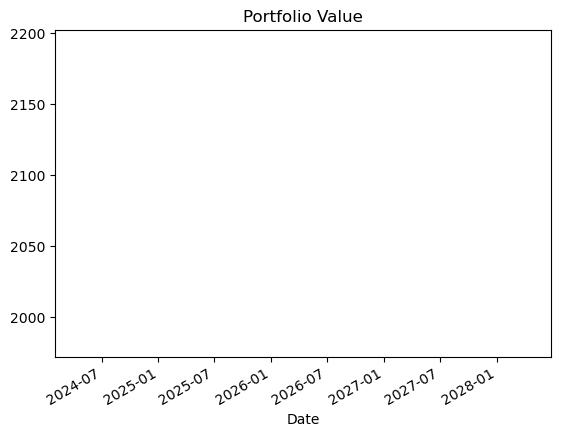

In [38]:
#Plot performance
portfolio_value.plot(title="Portfolio Value")

In [39]:
#Daily Returns
returns = portfolio_value.pct_change()
returns

Date
2026-04-15   NaN
dtype: float64

In [40]:
#Total Profit
portfolio_value.iloc[-1] - portfolio_value.iloc[0]

0.0

In [41]:
#Drawdown
drawdown = portfolio_value / portfolio_value.cummax() - 1
drawdown

Date
2026-04-15    0.0
dtype: float64

In [42]:
#Tables - just need to maintain the top two
#transactions_df
#price_history_df


#transactions_df   = raw trade history (add bought and sold shares into this df)
#prices_df         = latest prices (API)
#positions_df      = aggregated holdings 
#portfolio_df      = gains, value, weights
#price_history_df  = historical prices

In [43]:
###automating price_history_df####

In [44]:
prices_df

,Date,Ticker,Current Price
0,2026-04-15,BA.L,2239.000000
1,2026-04-15,BAB.L,1244.000000
2,2026-04-15,BARC.L,440.750000
3,2026-04-15,GLEN.L,561.200012
4,2026-04-15,LLOY.L,102.860001
5,2026-04-15,NAVY.L,914.007996
6,2026-04-15,VWRL.L,127.370003


In [45]:
tickers = prices_df["Ticker"].tolist()

In [46]:
tickers

['BA.L', 'BAB.L', 'BARC.L', 'GLEN.L', 'LLOY.L', 'NAVY.L', 'VWRL.L']

In [47]:
price_history_df = yf.download(
    tickers,
    start="2024-01-01",  # start date of your analysis
    auto_adjust=True
)["Close"]  # only close prices

[*********************100%***********************]  7 of 7 completed


In [48]:
price_history_df.head(5)

Ticker,BA.L,BAB.L,BARC.L,GLEN.L,LLOY.L,NAVY.L,VWRL.L
Date,,,,,,,
2024-01-02,1115.526611,419.929474,155.152679,468.459076,48.010189,NaN,90.480865
2024-01-03,1133.519043,440.725922,152.994476,458.264313,47.395962,NaN,89.572273
2024-01-04,1155.009888,445.325134,155.452423,459.013916,47.505817,NaN,89.572273
2024-01-05,1152.510864,442.325653,155.472427,462.761993,47.201199,NaN,89.156654
2024-01-08,1144.514282,439.926056,154.693069,456.865021,47.505817,NaN,89.185638


In [49]:
price_history_df = (
    price_history_df
    .stack()  # turn columns into rows
    .reset_index()
)
price_history_df.columns = ["Date", "Ticker", "Price"]

In [50]:
price_history_df.head(5)

,Date,Ticker,Price
0,2024-01-02,BA.L,1115.526611
1,2024-01-02,BAB.L,419.929474
2,2024-01-02,BARC.L,155.152679
3,2024-01-02,GLEN.L,468.459076
4,2024-01-02,LLOY.L,48.010189


In [51]:
#save so I don't redownload
#price_history_df.to_csv("price_history.csv", index=False)

In [52]:
#Load it later:
#price_history_df = pd.read_csv("price_history.csv", parse_dates=["date"])

In [53]:
#Update prices for new days

import datetime

today = pd.Timestamp.today().normalize()
last_date = price_history_df["Date"].max()

# only download if there's a new date
if last_date < today:
    new_prices = yf.download(
        tickers,
        start=last_date + pd.Timedelta(days=1),
        end=today + pd.Timedelta(days=1),
        auto_adjust=True
    )["Close"]

    # convert to long format
    new_prices = new_prices.stack().reset_index()
    new_prices.columns = ["Date", "Ticker", "Price"]

    # append to history
    price_history_df = pd.concat([price_history_df, new_prices], ignore_index=True)
    price_history_df = price_history_df.drop_duplicates(["Date", "Ticker"])

In [54]:
#After this, I have a complete historical price table that can be used with my existing portfolio calculation:

# Merge positions and calculate portfolio value
merged = price_history_df.merge(positions_df, on="Ticker")
merged["value"] = merged["Price"] * merged["Shares"]

portfolio_df = merged.groupby("Date")["value"].sum().reset_index(name="portfolio_value")

In [55]:
### Plotting Data on Charts ###

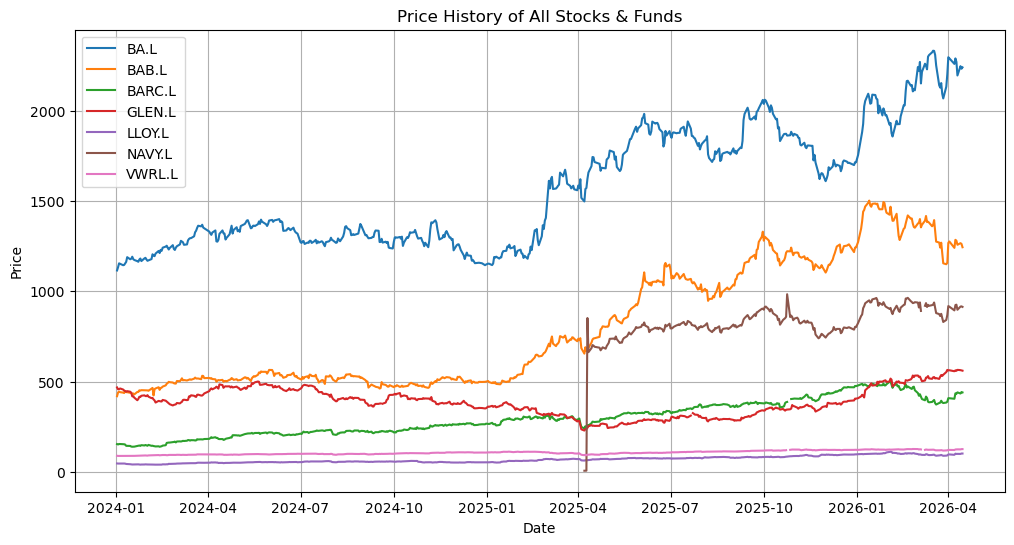

In [56]:
#Plot multiple stocks together
#Pivot to wide format: dates as index, tickers as columns
prices_wide = price_history_df.pivot(index="Date", columns="Ticker", values="Price")

plt.figure(figsize=(12,6))
for ticker in prices_wide.columns:
    plt.plot(prices_wide.index, prices_wide[ticker], label=ticker)

plt.title("Price History of All Stocks & Funds")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()

In [57]:
#visual:
#1. All individual stock prices
#2. Total portfolio value

In [58]:
#prep data
import matplotlib.pyplot as plt

# Pivot price_history_df to wide format: dates as index, tickers as columns
prices_wide = price_history_df.pivot(index="Date", columns="Ticker", values="Price")

# Calculate portfolio value
# Make sure positions_df exists with current holdings (columns: ticker, shares)
merged = price_history_df.merge(positions_df, on="Ticker")
merged["value"] = merged["Price"] * merged["Shares"]
portfolio_df = merged.groupby("Date")["value"].sum().reset_index(name="portfolio_value")
portfolio_df.set_index("Date", inplace=True)

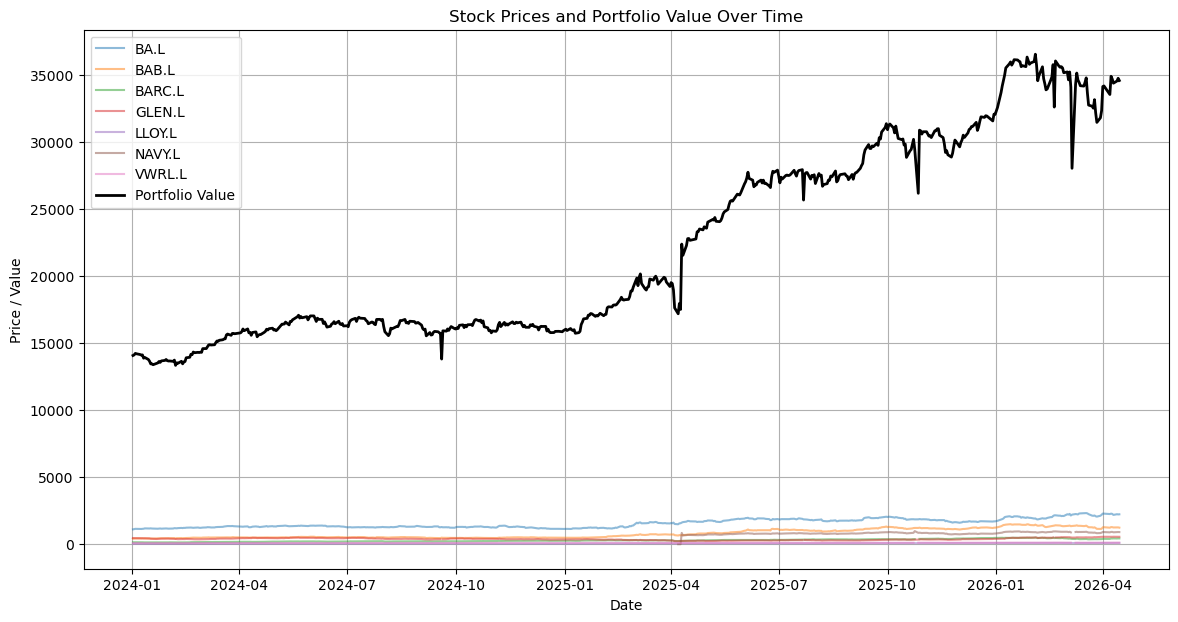

In [59]:
#Plot combined chart

plt.figure(figsize=(14,7))

# Plot individual stock prices (lighter color)
for ticker in prices_wide.columns:
    plt.plot(prices_wide.index, prices_wide[ticker], label=ticker, alpha=0.5)

# Plot portfolio value (bold)
plt.plot(portfolio_df.index, portfolio_df["portfolio_value"], label="Portfolio Value", color="black", linewidth=2)

plt.title("Stock Prices and Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Price / Value")
plt.grid(True)
plt.legend()
plt.show()

In [60]:
#Chart above also includes m portfolio value (which is the black line).

In [61]:
#I am downsampling price_history_df so that it is showing the weekly costs rather than the daily ones
#This will help me with forecasting as I shouldn't have any missing dates

# Convert Date column to datetime with error handling
price_history_df["Date"] = pd.to_datetime(price_history_df["Date"], errors='coerce')

# Drop rows with NaT values to prevent the error
price_history_df = price_history_df.dropna(subset=["Date"])

# Fix: Set both Date and Ticker as index before resampling
weekly = (
    price_history_df.set_index(["Date", "Ticker"])  # Set both as index
      .groupby(level="Ticker")                      # Group by the Ticker level
      .resample("W", level="Date")                  # Resample on the Date level
      .last()                                       # Last price of the week
      .reset_index()                                # Reset both indices to columns
)

print(weekly)

     Ticker       Date        Price
0      BA.L 2024-01-07  1152.510864
1      BA.L 2024-01-14  1188.995483
2      BA.L 2024-01-21  1173.502075
3      BA.L 2024-01-28  1167.504517
4      BA.L 2024-02-04  1171.502930
..      ...        ...          ...
769  VWRL.L 2026-03-22   120.500000
770  VWRL.L 2026-03-29   119.019997
771  VWRL.L 2026-04-05   122.800003
772  VWRL.L 2026-04-12   125.980003
773  VWRL.L 2026-04-19   127.370003

[774 rows x 3 columns]


In [62]:
weekly.to_csv("weekly_price_history_df.csv", index=False)

In [63]:
weekly

,Ticker,Date,Price
0,BA.L,2024-01-07,1152.510864
1,BA.L,2024-01-14,1188.995483
2,BA.L,2024-01-21,1173.502075
3,BA.L,2024-01-28,1167.504517
4,BA.L,2024-02-04,1171.502930
...,...,...,...
769,VWRL.L,2026-03-22,120.500000
770,VWRL.L,2026-03-29,119.019997
771,VWRL.L,2026-04-05,122.800003
772,VWRL.L,2026-04-12,125.980003


In [64]:
### FORECASTING Using the 'weekly' data frame

# First, install the prophet package
!pip install prophet

# Then import the modules
from prophet import Prophet
import pandas as pd

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


09:28:07 - cmdstanpy - INFO - Chain [1] start processing
09:28:07 - cmdstanpy - INFO - Chain [1] done processing


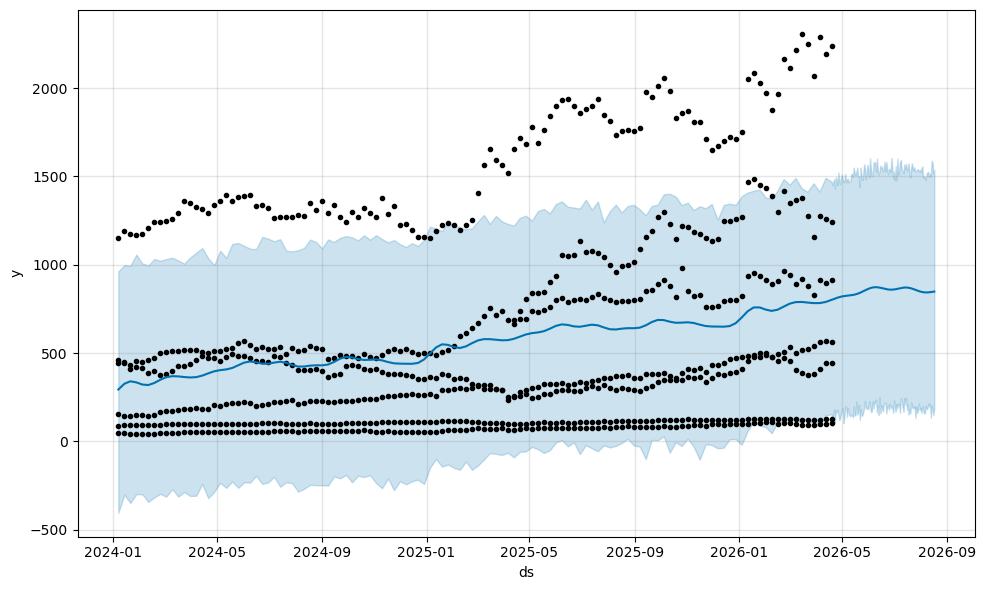

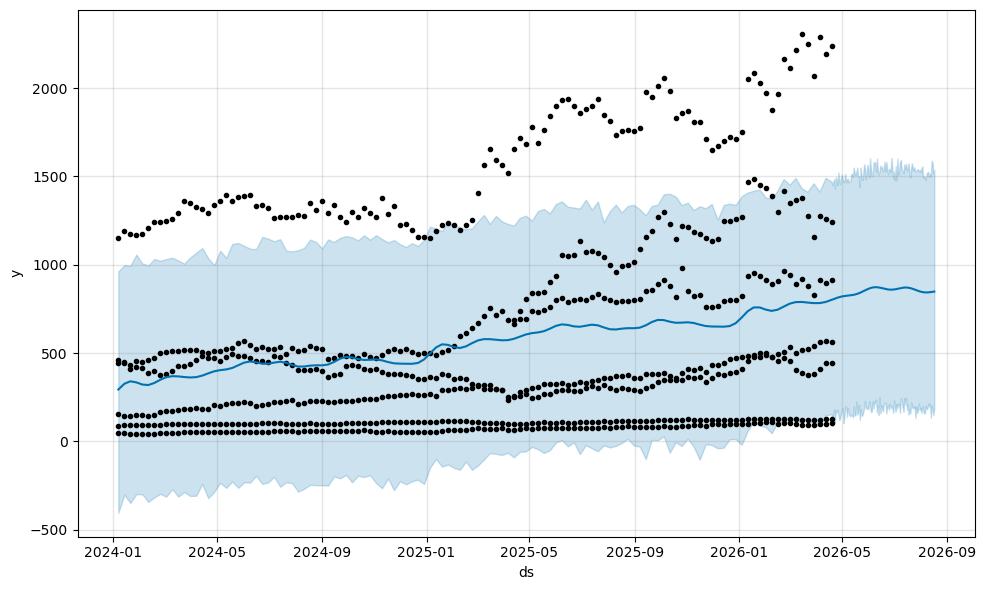

In [65]:
weekly = weekly.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(weekly)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)



In [66]:
weekly

,Ticker,ds,y
0,BA.L,2024-01-07,1152.510864
1,BA.L,2024-01-14,1188.995483
2,BA.L,2024-01-21,1173.502075
3,BA.L,2024-01-28,1167.504517
4,BA.L,2024-02-04,1171.502930
...,...,...,...
769,VWRL.L,2026-03-22,120.500000
770,VWRL.L,2026-03-29,119.019997
771,VWRL.L,2026-04-05,122.800003
772,VWRL.L,2026-04-12,125.980003


In [67]:
#I'll need to do the prophet forecast (code above) for each stock share price
#so I'll need to filter the weekly df by the ticker

In [68]:
#Created a df for each stock so that I can use prophet to calculate the forecast
BA_L = weekly[weekly["Ticker"] == "BA.L"]
BAB_L = weekly[weekly["Ticker"] == "BAB.L"]
BARC_L = weekly[weekly["Ticker"] == "BARC.L"]
GLEN_L = weekly[weekly["Ticker"] == "GLEN.L"]
LLOY_L = weekly[weekly["Ticker"] == "LLOY.L"]
NAVY_L = weekly[weekly["Ticker"] == "NAVY.L"]
VWRL_L = weekly[weekly["Ticker"] == "VWRL.L"]

09:28:08 - cmdstanpy - INFO - Chain [1] start processing
09:28:08 - cmdstanpy - INFO - Chain [1] done processing


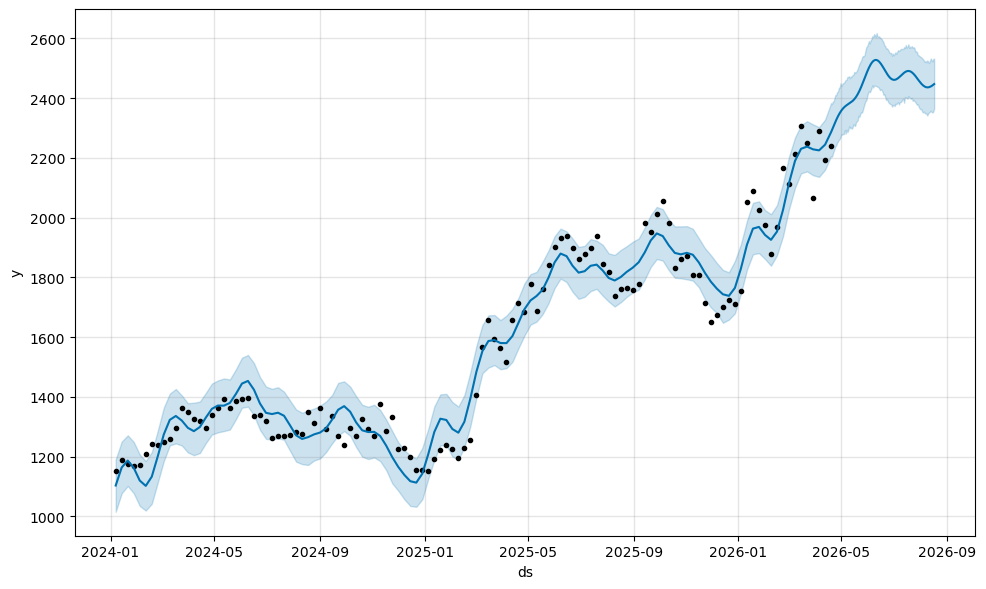

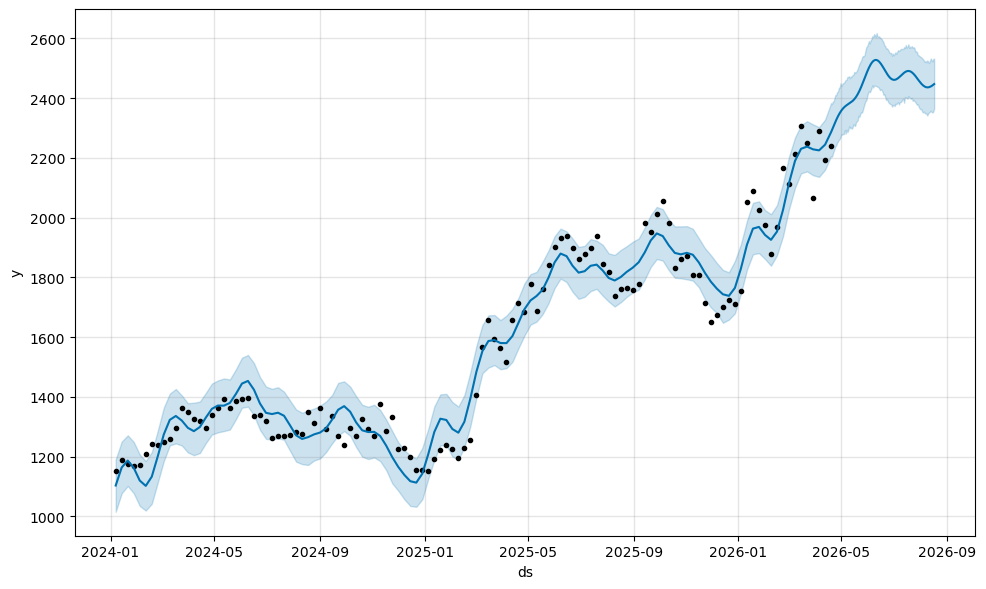

In [69]:
#BAE Forecast
BA_L= BA_L.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(BA_L)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)

09:28:09 - cmdstanpy - INFO - Chain [1] start processing
09:28:09 - cmdstanpy - INFO - Chain [1] done processing


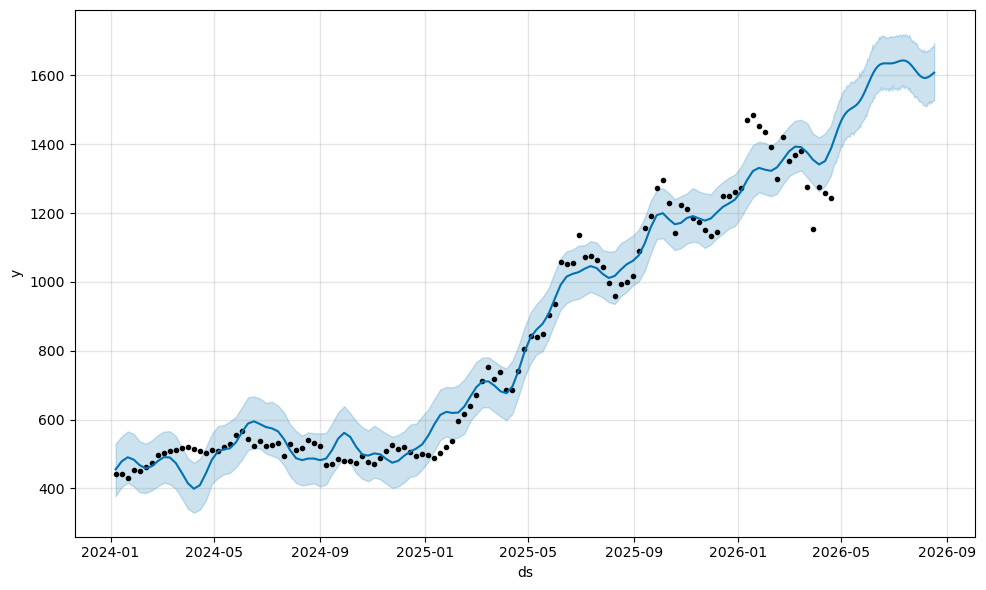

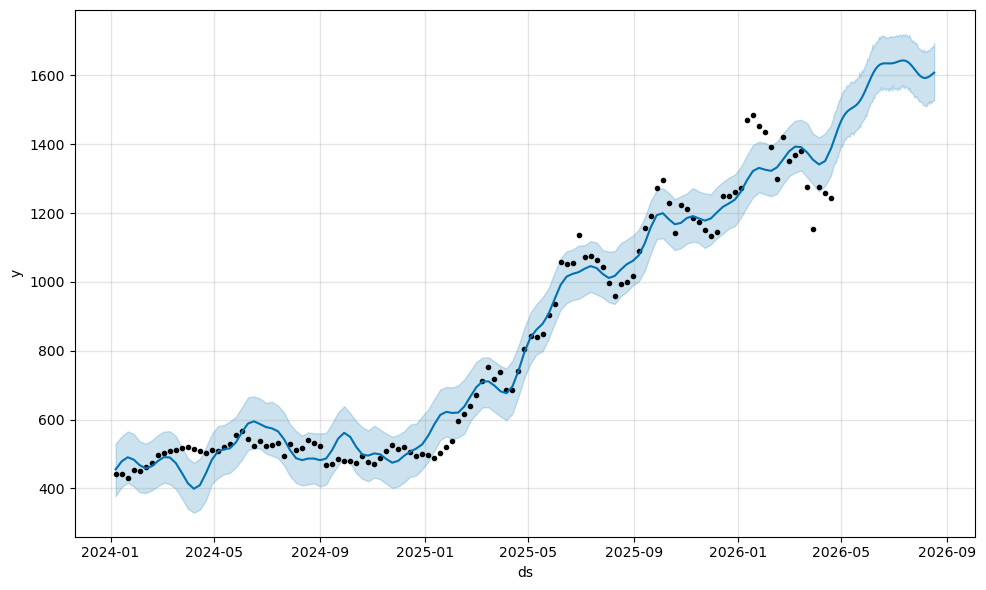

In [70]:
#Babcock Forecast
BAB_L = BAB_L.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(BAB_L)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)


09:28:10 - cmdstanpy - INFO - Chain [1] start processing
09:28:10 - cmdstanpy - INFO - Chain [1] done processing


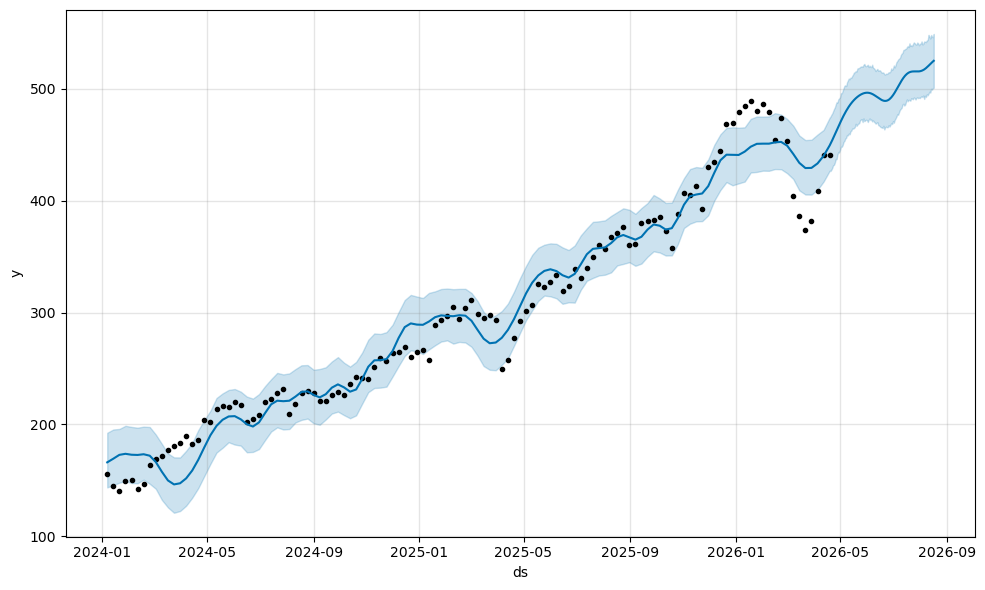

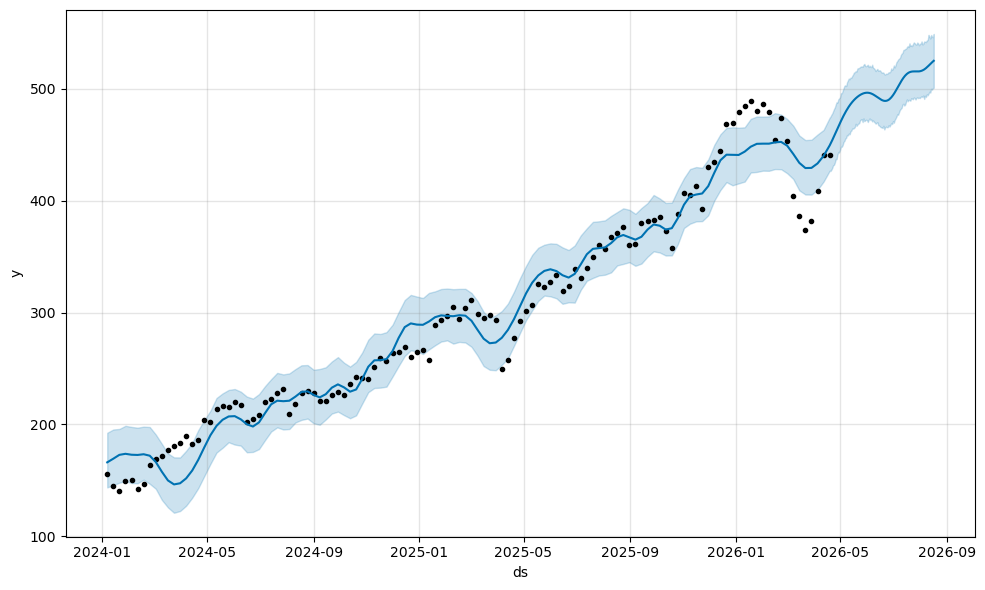

In [71]:
#Barclays Forecast
BARC_L= BARC_L.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(BARC_L)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)

09:28:12 - cmdstanpy - INFO - Chain [1] start processing
09:28:12 - cmdstanpy - INFO - Chain [1] done processing


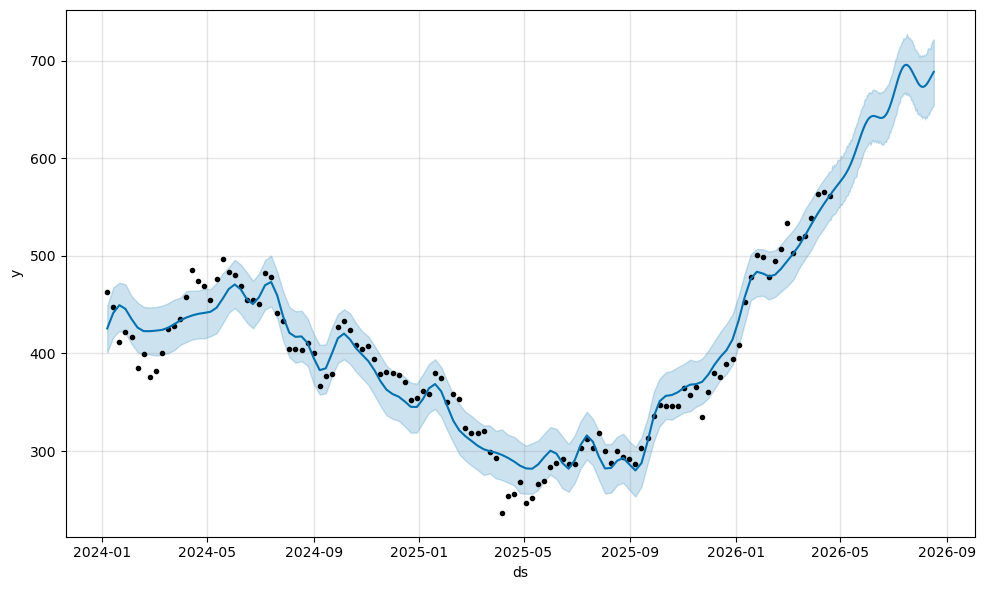

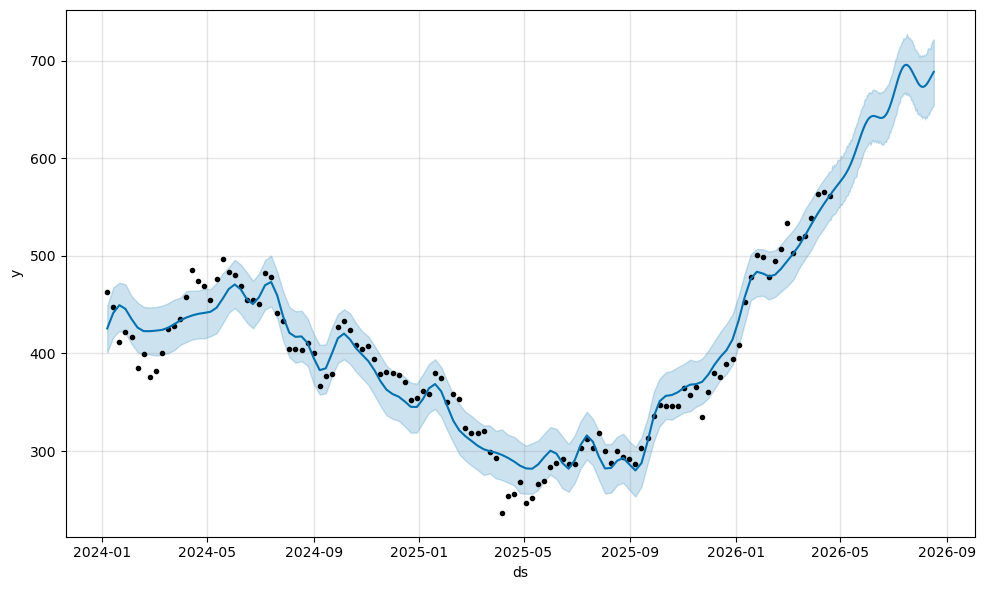

In [72]:
#Glencore Forecast
GLEN_L= GLEN_L.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(GLEN_L)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)

09:28:13 - cmdstanpy - INFO - Chain [1] start processing
09:28:13 - cmdstanpy - INFO - Chain [1] done processing


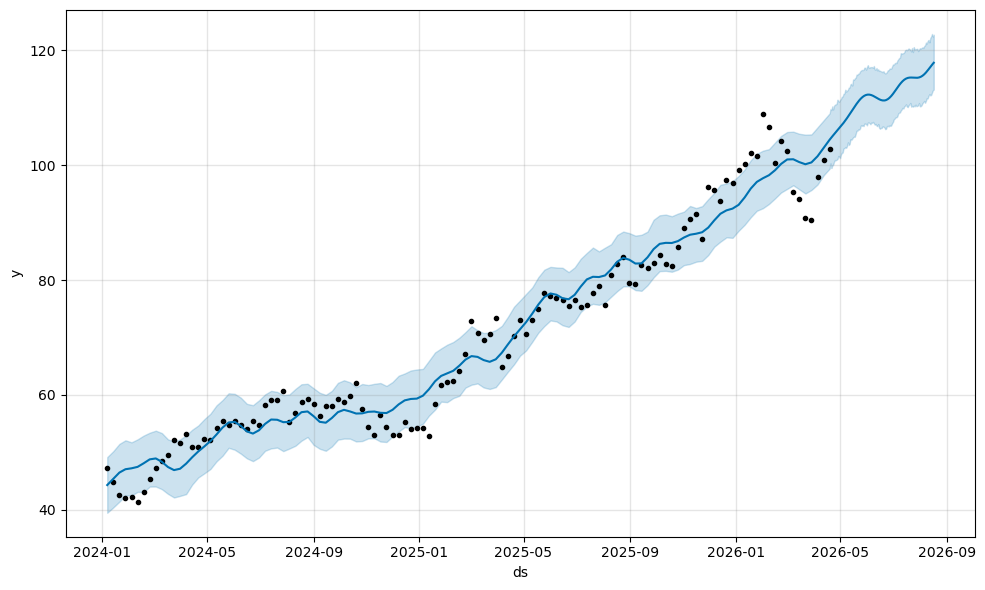

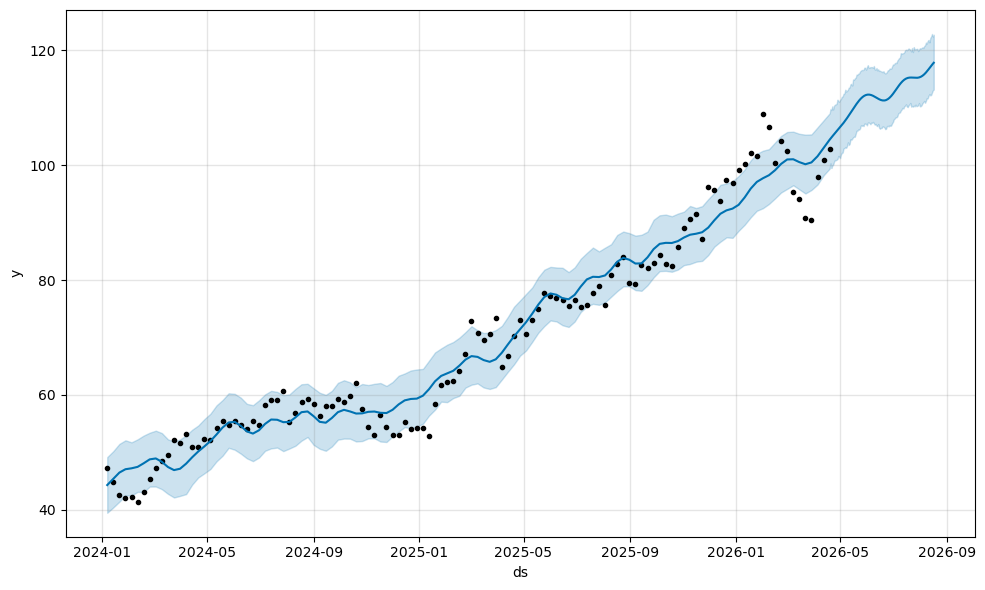

In [73]:
#Lloyd Forecast
LLOY_L= LLOY_L.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(LLOY_L)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)

09:28:14 - cmdstanpy - INFO - Chain [1] start processing
09:28:14 - cmdstanpy - INFO - Chain [1] done processing


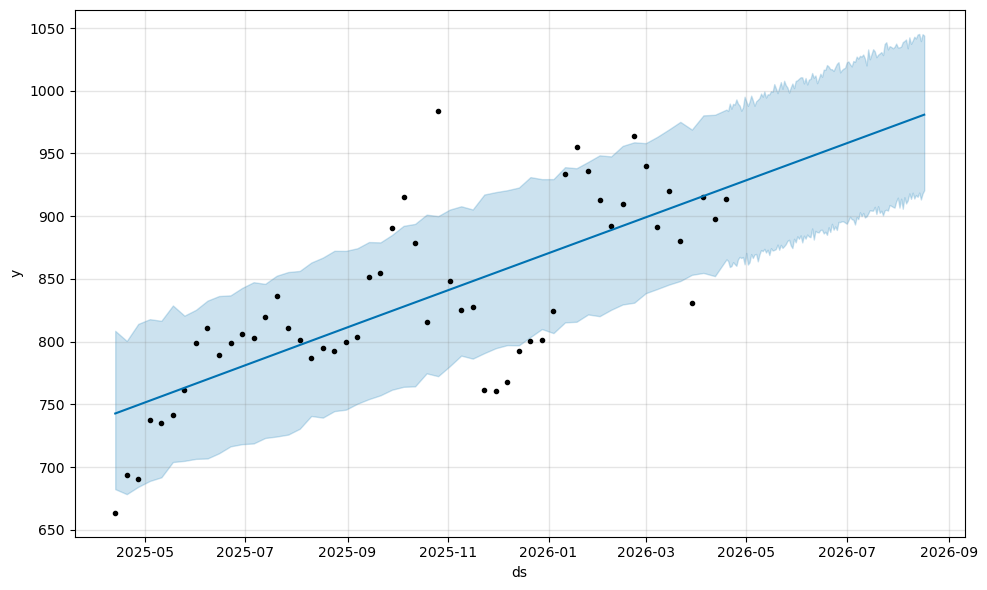

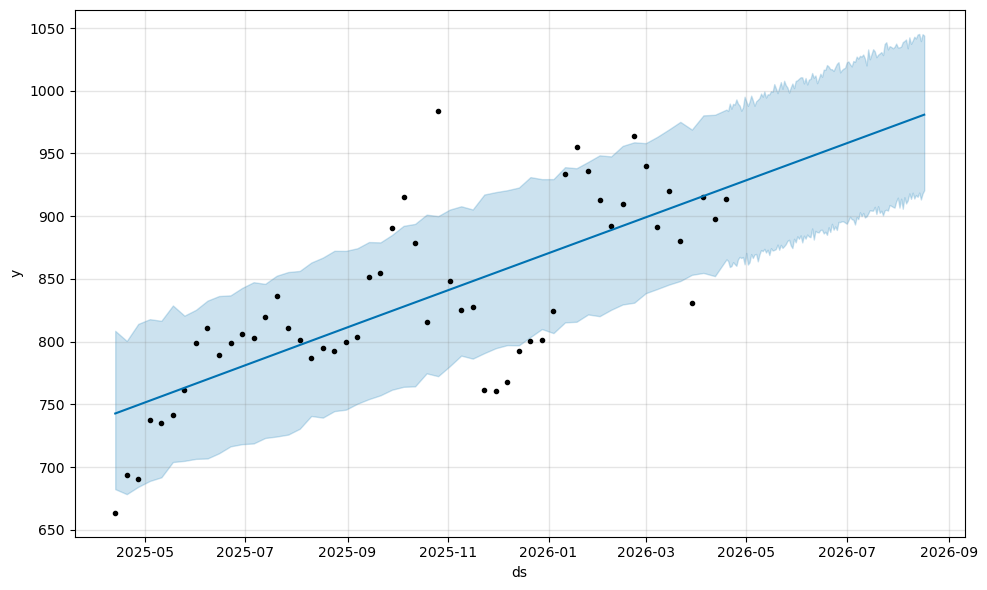

In [74]:
#Future of Euro Defence Forecast
NAVY_L= NAVY_L.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(NAVY_L)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)

09:28:15 - cmdstanpy - INFO - Chain [1] start processing
09:28:15 - cmdstanpy - INFO - Chain [1] done processing


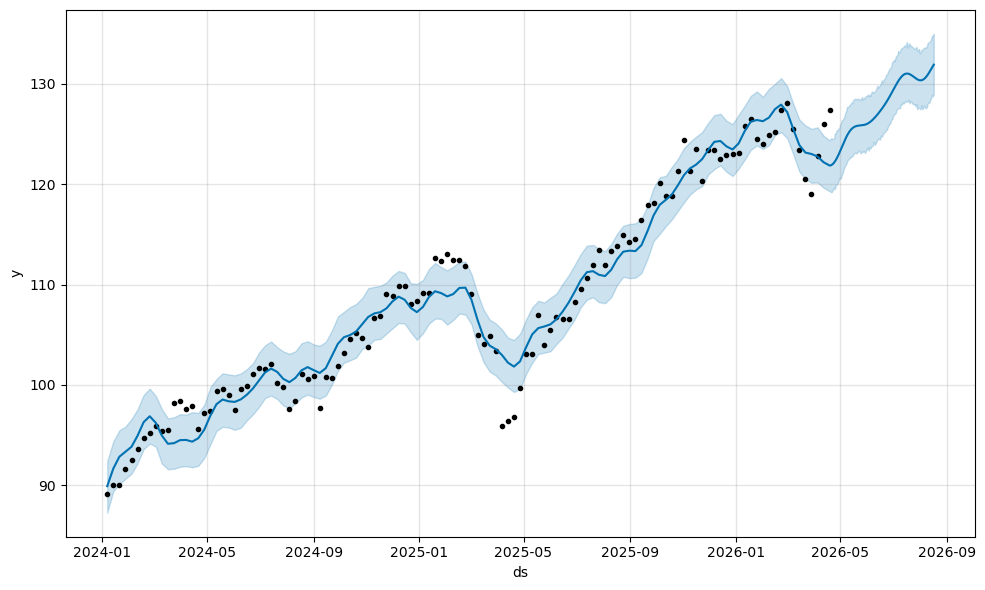

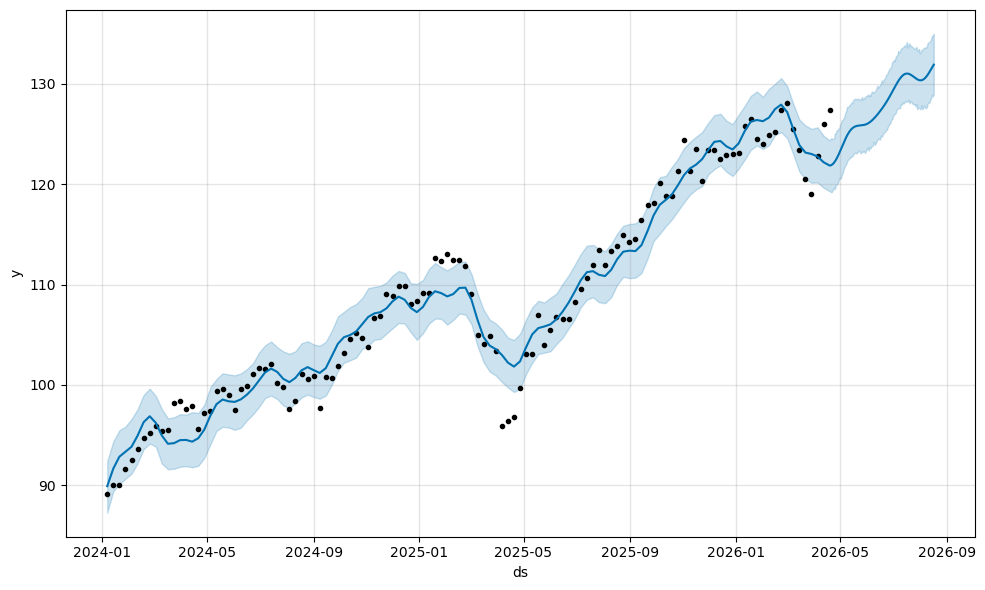

In [75]:
#Vanguard Forecast
VWRL_L= VWRL_L.rename(columns={"Date": "ds", "Price": "y"})

model = Prophet()
model.fit(VWRL_L)

future = model.make_future_dataframe(periods=120)
forecast = model.predict(future)

model.plot(forecast)